# Prediction of Geoeffective CMEs
Zhaoxin Yan, Yasser Abduallah, Jason T. L. Wang

Run all cells to load the pretrained fusion model, predict the test events, and display the confusion matrix in Fig. 7.

Copyright (c) 2026 Zhaoxin Yan.

## 1. Install dependencies

In [1]:
# Copyright (c) 2026 Zhaoxin Yan.
import importlib.util
import subprocess
import sys

packages = {"torch": "torch>=2.6", "torchvision": "torchvision>=0.21", "numpy": "numpy>=1.26", "matplotlib": "matplotlib>=3.8"}
missing = [spec for name, spec in packages.items() if importlib.util.find_spec(name) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
import torch
if tuple(int(v) for v in torch.__version__.split("+")[0].split(".")[:2]) < (2, 6):
    raise RuntimeError("Use PyTorch 2.6 or later and restart the notebook kernel.")
torch.set_num_threads(min(4, torch.get_num_threads()))

## 2. Load code and data

In [2]:
# Copyright (c) 2026 Zhaoxin Yan.
import os
import shutil
import urllib.request
import zipfile
from pathlib import Path

CODE_URL = "https://github.com/xysgszx/DeepGeoCME/archive/refs/heads/main.zip"
ASSETS_URL = "https://github.com/xysgszx/DeepGeoCME/releases/download/v1.0"
FILES = ("model.py", "data.py", "dnet_data.py", "reproduce_fig7.py", "test.csv", "assets_manifest.json")
local = Path(os.environ.get("FIG7_LOCAL_DIR", ".")).resolve()
if all((local / name).is_file() for name in FILES):
    WORK = local
else:
    WORK = Path("fig7_work").resolve()
    WORK.mkdir(exist_ok=True)
    archive = WORK / "code.zip"
    urllib.request.urlretrieve(CODE_URL, archive)
    with zipfile.ZipFile(archive) as z:
        prefixes = {name.split("/")[0] for name in z.namelist()}
        if len(prefixes) != 1:
            raise ValueError("Unexpected repository archive layout")
        prefix = prefixes.pop()
        for name in FILES:
            (WORK / name).write_bytes(z.read(prefix + "/" + name))
    archive.unlink()
sys.path.insert(0, str(WORK))
import reproduce_fig7 as rf
ckpt, tensor_dir = rf.fetch_assets(WORK / "assets", ASSETS_URL)
print("Model and testing data are ready.")

Model and testing data are ready.


## 3. Run prediction

In [3]:
# Copyright (c) 2026 Zhaoxin Yan.
device = "cuda" if torch.cuda.is_available() else "cpu"
ids, labels, probabilities = rf.predict(ckpt, tensor_dir, WORK / "test.csv", device)

  [ 1/33] 2011-03-03         label=0 p=0.051
  [ 2/33] 2011-03-24         label=0 p=0.021
  [ 3/33] 2011-05-25         label=1 p=0.901
  [ 4/33] 2011-09-24         label=1 p=0.935
  [ 5/33] 2012-02-23         label=1 p=0.930
  [ 6/33] 2012-03-04         label=0 p=0.021
  [ 7/33] 2012-09-01         label=1 p=0.023
  [ 8/33] 2012-10-27         label=1 p=0.940
  [ 9/33] 2012-11-23         label=0 p=0.021
  [10/33] 2013-04-11         label=0 p=0.701
  [11/33] 2013-08-21         label=0 p=0.020
  [12/33] 2013-12-11         label=0 p=0.020
  [13/33] 2014-02-12         label=0 p=0.021
  [14/33] 2014-09-10         label=1 p=0.938
  [15/33] 2014-12-17         label=1 p=0.936
  [16/33] 2015-03-14         label=1 p=0.940
  [17/33] 2015-04-06         label=0 p=0.023
  [18/33] 2015-06-20         label=1 p=0.882
  [19/33] 2015-07-09         label=1 p=0.940
  [20/33] 2015-12-28         label=1 p=0.926
  [21/33] 2019-05-07         label=1 p=0.324
  [22/33] 2021-05-23_0748    label=0 p=0.021
  [23/33] 

## 4. Display Fig. 7

figure saved -> fig7_confusion_matrix.png
Confusion matrix: {'TN': 14, 'FP': 2, 'FN': 2, 'TP': 15}
Saved fig7_confusion_matrix.png and predictions.csv.


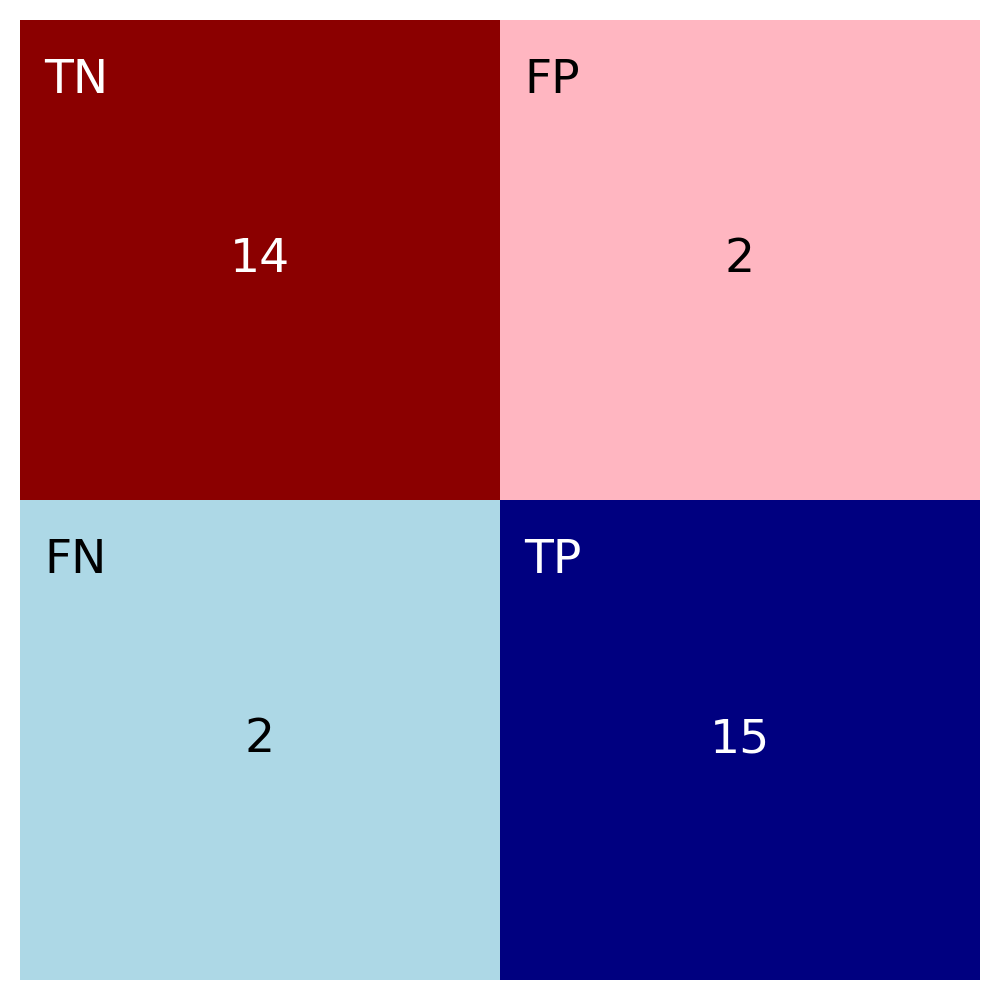

In [4]:
# Copyright (c) 2026 Zhaoxin Yan.
import csv
import matplotlib.pyplot as plt
from IPython.display import Image, display

counts = rf.confusion_counts(labels, probabilities)
output = WORK / "fig7_confusion_matrix.png"
figure = rf.plot_fig7(counts, output)
plt.close(figure)
display(Image(filename=str(output)))
print("Confusion matrix:", counts)
with (WORK / "predictions.csv").open("w", newline="") as stream:
    writer = csv.writer(stream)
    writer.writerow(["id", "label", "probability", "prediction"])
    writer.writerows((i, int(y), float(p), int(p >= rf.THRESHOLD))
                    for i, y, p in zip(ids, labels, probabilities))
print("Saved fig7_confusion_matrix.png and predictions.csv.")